# RAG Implementation with Google Vertex AI and LangChain

In [1]:
!python -m pip install langchain-community langchainhub langchain-chroma langchain langchain-experimental langchain-google-genai --quiet

In [2]:
!python -m pip install pypdf faiss-cpu langchain_text_splitters --quiet

In [1]:
import os

embedding_model_name = "models/gemini-embedding-001"
model_name = "gemini-2.5-flash"

In [2]:
doc_paths = [#"https://www.sebi.gov.in/sebi_data/attachdocs/jan-2024/1704171700950.pdf",
             "https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf",
             "https://s21.q4cdn.com/198919461/files/doc_downloads/press_kits/2016/Morningstar-Sustainable-Investing-Handbook.pdf"]

In [3]:
from langchain_community.document_loaders import PyPDFLoader

#loaders = [PyPDFLoader(pdf, extract_images=False,mode='single') for pdf in doc_paths]
loaders = [PyPDFLoader(pdf, extract_images=False) for pdf in doc_paths]
docs = []

for loader in loaders:
    doc = loader.load()
    docs.extend(doc)

In [4]:
len(docs)

25

In [5]:
docs[0]

Document(metadata={'producer': 'GPL Ghostscript 9.06', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2021-02-26T12:11:18+05:30', 'moddate': '2021-02-26T12:11:18+05:30', 'title': 'Microsoft Word - India Category_Definitions April 2021', 'author': 'KBelapu', 'source': 'https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf', 'total_pages': 12, 'page': 0, 'page_label': '1'}, page_content='? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total assets in large-cap stocks. \nMorningstar Category Index: S&P BSE 100 TR \n \nMid-Cap \nMid-Cap funds primar

In [6]:
# drop pages which have less than 100 characters (e.g. header pages, empty separater pages)
docs = [doc for doc in docs if len(doc.page_content.strip())>100]
len(docs)

24

In [7]:
# For all remaining document, checking the average characters count
sum(len(doc.page_content) for doc in docs)/len(docs)

1988.0833333333333

In [8]:
# split the documents(each pdf page as one document) , into multiple so that at max there are 3500 characters in one document, with overlap of 500 characters while splitting
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=3000, chunk_overlap=500)
splits = text_splitter.split_documents(docs)
len(splits)

27

In [9]:
print(splits[1].page_content)

©2019 Morningstar, Inc. All rights reserved. The information in this document is the property of Morningstar, Inc. Reproduction or transcription by any means, in whole or part, without  
the prior written consent of Morningstar, Inc., is prohibited. 
Category Definitions , India  | 26 February 2021  Page 2 of 12  
Multi- Cap 
Multi-Cap funds invest at least 75% of their total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. These funds 
will invest a minimum of 25% each in Large Cap, Mid Cap and Small Cap stocks. 
Morningstar Category Index: S&P BSE 500 TR 
 
 
Large & Mid- Cap 
Large & Mid-Cap funds primarily consist of stocks which are the Top 250 stocks by full market 
capitalization of the equity market. These funds invest at least 70% of total assets in Indian equities and 
the balance can be invested in other asset classes such as fixed income and overseas equities, among 
others. Funds in

In [10]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings = GoogleGenerativeAIEmbeddings(model=embedding_model_name)

In [11]:
# initializng the vector store using CHromaDB
#from langchain_community.vectorstores import FAISS
#from langchain.embeddings import HuggingFaceBgeEmbeddings
#embedding_model_name = "BAAI/bge-large-en-v1.5"
#embeddings = HuggingFaceBgeEmbeddings(model_name=embedding_model_name,)

In [12]:
import os
vector_db_path = "VectorDB_Chroma"
os.makedirs(vector_db_path,exist_ok=True)

In [13]:
from langchain_chroma import Chroma
vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings,
                                    persist_directory=vector_db_path,collection_name="morningstar3",
                                    collection_metadata={"use_type":"TRAINING AND EXPERIMENTATION"})

In [14]:
print("Number of docs dumped into vector DB")
print(len(vectorstore.get()['ids']))


Number of docs dumped into vector DB
27


In [16]:
# using vector db object to initialize a retriever object - to perform vector search/retrieval
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 2})

In [17]:
retrieved_docs = retriever.invoke("What is Large Cap equity fund")
len(retrieved_docs)

2

In [18]:
ret_docs = vectorstore.similarity_search_with_score("What is Large Cap equity fund",k=2)
print(ret_docs[0])

(Document(id='d268e3a5-5673-4388-8239-5692eeb1b666', metadata={'source': 'https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf', 'moddate': '2021-02-26T12:11:18+05:30', 'page_label': '1', 'page': 0, 'creationdate': '2021-02-26T12:11:18+05:30', 'total_pages': 12, 'creator': 'PScript5.dll Version 5.2.2', 'producer': 'GPL Ghostscript 9.06', 'title': 'Microsoft Word - India Category_Definitions April 2021', 'author': 'KBelapu'}, page_content='? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total assets in large-cap stocks. \nMorningstar Category Index: S&P BS

In [19]:
print(retrieved_docs[0].page_content)

? 
 
 
 
 
 
 
 
 
 
 
 
Categor y Definitions  
India 
Equity  
 
Large-Cap 
Large-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of 
the equity market. These funds invest at least 80% of total assets in Indian equities and the balance can 
be invested in other asset classes such as fixed income and overseas equities, among others. Funds in 
this category would invest at least 80% of their total assets in large-cap stocks. 
Morningstar Category Index: S&P BSE 100 TR 
 
Mid-Cap 
Mid-Cap funds primarily consist of stocks ranked 101st to 250th by full market capitalization of the 
equity market. These funds invest at least 65% of total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. Funds in this 
category would invest at least 65% of their total assets in mid-cap stocks. 
Morningstar Category Index: S&P BSE Mid Cap TR 
 
Small-Cap 
Small-Cap fun

In [20]:
print(retrieved_docs[1].page_content)

©2019 Morningstar, Inc. All rights reserved. The information in this document is the property of Morningstar, Inc. Reproduction or transcription by any means, in whole or part, without  
the prior written consent of Morningstar, Inc., is prohibited. 
Category Definitions , India  | 26 February 2021  Page 2 of 12  
Multi- Cap 
Multi-Cap funds invest at least 75% of their total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. These funds 
will invest a minimum of 25% each in Large Cap, Mid Cap and Small Cap stocks. 
Morningstar Category Index: S&P BSE 500 TR 
 
 
Large & Mid- Cap 
Large & Mid-Cap funds primarily consist of stocks which are the Top 250 stocks by full market 
capitalization of the equity market. These funds invest at least 70% of total assets in Indian equities and 
the balance can be invested in other asset classes such as fixed income and overseas equities, among 
others. Funds in

### Implementing RAG Chain

In [34]:
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough

message = """
Answer this question using the provided context only. 
If the context does not have the content to answer the question, say context is irrelevant.
Do not make up the answer, do not provide answer from outside the context.
{question}

Context:
{context}
"""

prompt = PromptTemplate.from_template(message)
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='\nAnswer this question using the provided context only. \nIf the context does not have the content to answer the question, say context is irrelevant.\nDo not make up the answer, do not provide answer from outside the context.\n{question}\n\nContext:\n{context}\n')

In [35]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model_name, model_provider="google_genai")



## RAG Chain with Langgraph - with Routing

In [36]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START

class ragstate(TypedDict):
    user_query:str
    retrived_context:list
    response:str

In [37]:
# node 1
def retriver_node(state:ragstate)->ragstate:
    query = state['user_query']
    output = retriever.invoke(query)
    return {'retrived_context':output}


# node 2
def generation(state:ragstate)->ragstate:
    query = state['user_query']
    context = state['retrived_context']
    context = ' \n'.join([doc.page_content for doc in context])
    prompt_content = prompt.invoke({"context":context,"question":query})
    response = llm.invoke(prompt_content)
    return {'response':response}
    


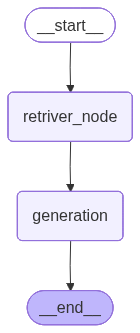

In [38]:
builder = StateGraph(ragstate)
builder.add_sequence([retriver_node,generation])
builder.set_entry_point("retriver_node")
builder.add_edge("generation",END)
graph = builder.compile()
graph

In [39]:
graph.invoke({"user_query":"What is Mid cap market?"})

{'user_query': 'What is Mid cap market?',
 'retrived_context': [Document(id='d268e3a5-5673-4388-8239-5692eeb1b666', metadata={'page_label': '1', 'title': 'Microsoft Word - India Category_Definitions April 2021', 'page': 0, 'creator': 'PScript5.dll Version 5.2.2', 'producer': 'GPL Ghostscript 9.06', 'moddate': '2021-02-26T12:11:18+05:30', 'source': 'https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf', 'creationdate': '2021-02-26T12:11:18+05:30', 'author': 'KBelapu', 'total_pages': 12}, page_content='? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total a